# Fleet Reliability Data Engineering Platform

## Objective:

Detect anomalous vehicles using engineered fleet reliability features.

This notebook identifies anomalous vehicles using engineered fleet reliability features.

## Approach
- Select reliability-related vehicle features
- Standardize features
- Train Isolation Forest
- Identify anomalous vehicles
- Explain anomaly drivers using feature z-scores
- Generate anomaly summaries by model and region

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [3]:
feature_path = "data/featured"
output_path = "outputs/anomaly"

os.makedirs(output_path, exist_ok=True)

In [4]:
from google.colab import files
uploaded = files.upload()

Saving vehicle_features.csv to vehicle_features.csv


In [5]:
vehicle_features = pd.read_csv(f"vehicle_features.csv")

print("Shape:", vehicle_features.shape)
vehicle_features.head()

Shape: (50000, 117)


,vehicle_id,vin,model,model_year,battery_type,delivery_date,region,mileage,fleet_type,vehicle_age_days,vehicle_age_months,vehicle_age_years,mileage_band,total_services,repairs_last_30d,repairs_last_90d,repairs_last_180d,avg_repair_cost,max_repair_cost,total_repair_cost,avg_downtime_days,max_downtime_days,total_downtime_days,repeat_issue_count,last_service_date,days_since_last_service,repeat_repair_ratio,critical_severity_count,high_severity_count,low_severity_count,medium_severity_count,battery_issue_count,brake_issue_count,electrical_issue_count,hvac_issue_count,motor_issue_count,software_issue_count,suspension_issue_count,telemetry_records,avg_battery_health,min_battery_health,avg_motor_temp,max_motor_temp,avg_brake_temp,max_brake_temp,avg_tire_pressure_alerts,total_tire_pressure_alerts,avg_warning_count,max_warning_count,total_warning_count,recent_telemetry_30d,recent_telemetry_90d,last_telemetry_date,days_since_last_telemetry,latest_telemetry_date,latest_battery_health,latest_motor_temp,latest_brake_temp,latest_tire_pressure_alerts,latest_software_version,latest_warning_count,total_claims,claims_last_90d,claims_last_180d,total_claim_amount,avg_claim_amount,max_claim_amount,last_claim_date,days_since_last_claim,approved_claim_count,pending_claim_count,rejected_claim_count,total_failures,failures_last_90d,failures_last_180d,replaced_count,last_failure_date,days_since_last_failure,electrical_fault,mechanical_failure,software_error,thermal_issue,wear,12v_battery,abs_module,ac_compressor,autopilot_computer,battery_pack,bms,brake_pads,brake_rotor,cabin_heater,charging_port,control_arm,cooling_fan,drive_unit,firmware,infotainment_module,inverter,motor_controller,sensor_module,shock_absorber,suspension_link,wiring_harness,claims_per_service,failures_per_service,avg_cost_per_downtime_day,warning_to_failure_ratio,service_per_year,claim_per_year,failure_per_year,high_repair_frequency_flag,high_warning_flag,low_battery_health_flag,high_claim_cost_flag,repeat_repair_flag,fleet_risk_score
0,1,5YJ00000000000001,Model 3,2025,NCA,2020-04-11,Asia Pacific,1269,Retail,2150,71.7,5.89,Low,9.0,0.0,1.0,1.0,1641.293333,5206.91,14771.64,2.633333,5.4,23.7,1.0,2025-12-14,77.0,0.111111,0.0,3.0,4.0,2.0,1.0,0.0,1.0,1.0,1.0,4.0,1.0,8.0,97.595000,95.70,70.687500,85.57,57.071250,69.930000,0.250000,2.0,1.500000,3.0,12.0,1.0,2.0,2026-02-02,27.0,2026-02-02,97.86,70.95,47.300000,0.0,2024.38.1,1.0,3.0,0.0,1.0,3621.34,1207.113333,1553.92,2025-10-14,138.0,0.0,3.0,0.0,3.0,0.0,0.0,2.0,2024-06-27,612.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.333333,623.275949,4.000000,1.528014,0.509338,0.509338,0,0,0,0,0,0
1,2,5YJ00000000000002,Model Y,2025,NCM,2019-01-22,North America,3505,Retail,2595,86.5,7.11,Low,7.0,0.0,1.0,2.0,1715.110000,3449.08,12005.77,2.457143,4.0,17.2,1.0,2026-01-01,59.0,0.142857,0.0,3.0,3.0,1.0,0.0,0.0,1.0,1.0,2.0,0.0,3.0,15.0,97.442667,92.61,70.212667,96.13,60.308000,70.240000,0.466667,7.0,1.600000,4.0,24.0,1.0,6.0,2026-02-10,19.0,2026-02-10,98.84,76.21,54.230000,1.0,2024.38.1,2.0,3.0,0.0,0.0,4276.06,1425.353333,2354.44,2024-04-13,687.0,2.0,0.0,1.0,3.0,0.0,0.0,2.0,2024-07-29,580.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.428571,0.428571,698.009884,8.000000,0.984529,0.421941,0.421941,0,0,0,0,0,0
2,3,5YJ00000000000003,Model 3,2023,LFP,2024-08-30,Europe,58323,Retail,548,18.3,1.50,High,4.0,0.0,0.0,2.0,1585.157500,2295.66,6340.63,4.000000,6.4,16.0,1.0,2025-11-20,101.0,0.250000,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,6.0,92.931667,89.57,66.558333,75.42,59.407898,72.692421,0.333333,2.0,1.833333,3.0,11.0,2.0,3.0,2026-02-22,7.0,2026-02-22,97.26,69.11,69.177330,1.0,2024.38.1,3.0,1.0,0.0,0.0,676.66,676.660000,676.66,2023-05-31,1005.0,0.0,1.0,0.0,7.0,0.0,0.0,7.0,2025-02-18,376.0,1.0,0.0,3.0,1.0,2.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.250000,1.750000,396.289375,1.571429,2.6666

In [6]:
anomaly_features = [
    "total_services",
    "repairs_last_30d",
    "repairs_last_90d",
    "repairs_last_180d",
    "avg_repair_cost",
    "total_repair_cost",
    "avg_downtime_days",
    "total_downtime_days",
    "repeat_issue_count",
    "repeat_repair_ratio",
    "total_claims",
    "claims_last_90d",
    "total_claim_amount",
    "avg_claim_amount",
    "total_failures",
    "failures_last_90d",
    "replaced_count",
    "avg_battery_health",
    "min_battery_health",
    "avg_warning_count",
    "max_warning_count",
    "total_warning_count",
    "service_per_year",
    "claim_per_year",
    "failure_per_year",
    "fleet_risk_score"
]

X = vehicle_features[anomaly_features].copy()
X.head()

,total_services,repairs_last_30d,repairs_last_90d,repairs_last_180d,avg_repair_cost,total_repair_cost,avg_downtime_days,total_downtime_days,repeat_issue_count,repeat_repair_ratio,total_claims,claims_last_90d,total_claim_amount,avg_claim_amount,total_failures,failures_last_90d,replaced_count,avg_battery_health,min_battery_health,avg_warning_count,max_warning_count,total_warning_count,service_per_year,claim_per_year,failure_per_year,fleet_risk_score
0,9.0,0.0,1.0,1.0,1641.293333,14771.64,2.633333,23.7,1.0,0.111111,3.0,0.0,3621.34,1207.113333,3.0,0.0,2.0,97.595000,95.70,1.500000,3.0,12.0,1.528014,0.509338,0.509338,0
1,7.0,0.0,1.0,2.0,1715.110000,12005.77,2.457143,17.2,1.0,0.142857,3.0,0.0,4276.06,1425.353333,3.0,0.0,2.0,97.442667,92.61,1.600000,4.0,24.0,0.984529,0.421941,0.421941,0
2,4.0,0.0,0.0,2.0,1585.157500,6340.63,4.000000,16.0,1.0,0.250000,1.0,0.0,676.66,676.660000,7.0,0.0,7.0,92.931667,89.57,1.833333,3.0,11.0,2.666667,0.666667,4.666667,0
3,3.0,0.0,0.0,0.0,1760.020000,5280.06,4.366667,13.1,1.0,0.333333,2.0,0.0,4122.56,2061.280000,2.0,0.0,2.0,81.323571,75.99,2.785714,7.0,39.0,18.750000,12.500000,12.500000,2
4,2.0,0.0,0.0,0.0,721.215000,1442.43,4.550000,9.1,0.0,0.000000,2.0,1.0,9909.76,4954.880000,4.0,0.0,3.0,93.283636,89.25,2.090909,4.0,23.0,0.704225,0.704225,1.408451,0


In [7]:
print(X.isnull().sum().sort_values(ascending=False))

total_services         0
repairs_last_30d       0
repairs_last_90d       0
repairs_last_180d      0
avg_repair_cost        0
total_repair_cost      0
avg_downtime_days      0
total_downtime_days    0
repeat_issue_count     0
repeat_repair_ratio    0
total_claims           0
claims_last_90d        0
total_claim_amount     0
avg_claim_amount       0
total_failures         0
failures_last_90d      0
replaced_count         0
avg_battery_health     0
min_battery_health     0
avg_warning_count      0
max_warning_count      0
total_warning_count    0
service_per_year       0
claim_per_year         0
failure_per_year       0
fleet_risk_score       0
dtype: int64


In [8]:
X = X.fillna(0)

# Scale Features

Isolation Forest does not strictly require scaling, but scaling helps when features have very different ranges.

In [9]:
# Scale Features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (50000, 26)


# Train Isolation Forest

Set contamination to a small proportion of anomalies.

In [10]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

iso_forest.fit(X_scaled)

IsolationForest(contamination=0.03, n_estimators=200, random_state=42)

# Predict anomalies

Isolation Forest returns: -1 for anomaly & 1 for normal

In [11]:
vehicle_features["anomaly_label"] = iso_forest.predict(X_scaled)
vehicle_features["anomaly_flag"] = vehicle_features["anomaly_label"].apply(lambda x: 1 if x == -1 else 0)

vehicle_features["anomaly_score"] = iso_forest.decision_function(X_scaled)

# Check anomaly counts

In [12]:
print("Normal vehicles:", (vehicle_features["anomaly_flag"] == 0).sum())
print("Anomalous vehicles:", (vehicle_features["anomaly_flag"] == 1).sum())

Normal vehicles: 48500
Anomalous vehicles: 1500


# Preview anomalous vehicles

In [13]:
anomalies = vehicle_features[vehicle_features["anomaly_flag"] == 1].copy()

anomalies[[
    "vehicle_id",
    "model",
    "region",
    "fleet_risk_score",
    "total_services",
    "total_failures",
    "total_claim_amount",
    "avg_battery_health",
    "avg_warning_count",
    "anomaly_score"
]].head(10)

,vehicle_id,model,region,fleet_risk_score,total_services,total_failures,total_claim_amount,avg_battery_health,avg_warning_count,anomaly_score
3,4,Model 3,North America,2,3.0,2.0,4122.56,81.323571,2.785714,-0.013601
36,37,Cybertruck,North America,2,10.0,2.0,9429.61,83.948000,4.800000,-0.001210
65,66,Model 3,Asia Pacific,0,11.0,4.0,1056.08,97.432500,2.166667,-0.033106
77,78,Model Y,Europe,3,3.0,3.0,17864.67,82.083333,3.500000,-0.004319
208,209,Model Y,North America,3,9.0,2.0,11977.24,84.342000,3.600000,-0.061306
232,233,Model Y,Asia Pacific,2,6.0,1.0,19896.97,81.596364,2.909091,-0.014920
237,238,Model 3,North America,2,11.0,2.0,14206.20,82.944615,3.230769,-0.014775
256,257,Model Y,North America,2,4.0,5.0,12327.22,80.340000,3.285714,-0.004413
317,318,Model X,North America,2,9.0,3.0,15703.88,81.363636,2.727273,-0.007729
321,322,Model X,North America,2,2.0,5.0,22791.71,91.486000,1.600000,-0.051169


# Sort by strongest anomalies

Lower score usually means more anomalous.

In [14]:
top_anomalies = anomalies.sort_values("anomaly_score").copy()

top_anomalies[[
    "vehicle_id",
    "model",
    "region",
    "fleet_risk_score",
    "total_services",
    "total_failures",
    "total_claim_amount",
    "avg_battery_health",
    "avg_warning_count",
    "anomaly_score"
]].head(20)

,vehicle_id,model,region,fleet_risk_score,total_services,total_failures,total_claim_amount,avg_battery_health,avg_warning_count,anomaly_score
25208,25209,Model 3,North America,3,9.0,6.0,7230.15,84.871250,4.125000,-0.148909
36985,36986,Model 3,Europe,1,9.0,6.0,7106.24,88.689286,3.714286,-0.142414
13095,13096,Model Y,North America,0,14.0,4.0,0.00,85.230000,3.307692,-0.141091
14308,14309,Model Y,Europe,2,10.0,0.0,17557.43,86.031111,2.444444,-0.137200
16818,16819,Cybertruck,Asia Pacific,2,15.0,4.0,0.00,81.064545,3.000000,-0.134230
44536,44537,Model Y,Asia Pacific,2,10.0,6.0,19247.66,81.176875,2.312500,-0.126624
21175,21176,Model Y,North America,2,10.0,3.0,24452.84,90.088333,3.500000,-0.122046
20368,20369,Model S,Europe,2,13.0,1.0,1181.07,85.112500,2.250000,-0.121453
26586,26587,Model 3,North America,2,13.0,7.0,0.00,83.605000,2.687500,-0.119696
46760,46761,Model Y,North America,3,9.0,3.0,28362.63,82.395714,3.857143,-0.118293


# Compute z-scores for selected features

This helps explain why a vehicle may have been flagged.

In [15]:
zscore_df = pd.DataFrame(X_scaled, columns=anomaly_features)
zscore_df["vehicle_id"] = vehicle_features["vehicle_id"].values
zscore_df.head()

,total_services,repairs_last_30d,repairs_last_90d,repairs_last_180d,avg_repair_cost,total_repair_cost,avg_downtime_days,total_downtime_days,repeat_issue_count,repeat_repair_ratio,total_claims,claims_last_90d,total_claim_amount,avg_claim_amount,total_failures,failures_last_90d,replaced_count,avg_battery_health,min_battery_health,avg_warning_count,max_warning_count,total_warning_count,service_per_year,claim_per_year,failure_per_year,fleet_risk_score,vehicle_id
0,1.231753,-0.313022,1.315001,0.550740,-0.287523,0.563836,-1.103965,0.205031,0.091908,-0.239732,0.707517,-0.311934,-0.300613,-0.525024,0.386712,-0.337509,0.148839,1.252432,1.657720,-0.912498,-1.074950,-0.966590,-0.333175,-0.286873,-0.342700,-0.648143,1
1,0.410584,-0.313022,1.315001,1.860467,-0.193306,0.122260,-1.305392,-0.438653,0.091908,-0.048838,0.707517,-0.311934,-0.168881,-0.411367,0.386712,-0.337509,0.148839,1.221057,1.062585,-0.778282,-0.405691,0.216350,-0.439655,-0.331664,-0.380878,-0.648143,2
2,-0.821169,-0.313022,-0.542135,1.860467,-0.359173,-0.782192,0.458460,-0.557487,0.091908,0.595427,-0.707517,-0.311934,-0.893094,-0.801280,2.964794,-0.337509,3.870561,0.291962,0.477080,-0.465112,-1.074950,-1.065168,-0.110091,-0.206244,1.473355,-0.648143,3
3,-1.231753,-0.313022,-0.542135,-0.758987,-0.135984,-0.951514,0.877647,-0.844670,0.091908,1.096522,0.000000,-0.311934,-0.199765,-0.080182,-0.257808,-0.337509,0.148839,-2.098866,-2.138432,0.813136,1.602085,1.695024,3.040951,5.858242,4.895206,2.429313,4
4,-1.642337,-0.313022,-0.542135,-0.758987,-1.461886,-1.564199,1.087241,-1.240783,-0.927707,-0.907859,0.000000,2.884764,0.964642,1.426780,1.031233,-0.337509,0.893183,0.364455,0.415448,-0.119404,-0.405691,0.117771,-0.494572,-0.186995,0.050061,-0.648143,5


# Function to identify strongest anomaly reasons

In [16]:
def top_anomaly_reasons(row, feature_cols, top_n=3):
    abs_vals = row[feature_cols].abs().sort_values(ascending=False)
    return ", ".join(abs_vals.head(top_n).index.tolist())

# Add anomaly reason column

In [17]:
zscore_df["top_anomaly_drivers"] = zscore_df.apply(
    lambda row: top_anomaly_reasons(row, anomaly_features, top_n=3),
    axis=1
)

vehicle_features = vehicle_features.merge(
    zscore_df[["vehicle_id", "top_anomaly_drivers"]],
    on="vehicle_id",
    how="left"
)

vehicle_features.head()

,vehicle_id,vin,model,model_year,battery_type,delivery_date,region,mileage,fleet_type,vehicle_age_days,vehicle_age_months,vehicle_age_years,mileage_band,total_services,repairs_last_30d,repairs_last_90d,repairs_last_180d,avg_repair_cost,max_repair_cost,total_repair_cost,avg_downtime_days,max_downtime_days,total_downtime_days,repeat_issue_count,last_service_date,days_since_last_service,repeat_repair_ratio,critical_severity_count,high_severity_count,low_severity_count,medium_severity_count,battery_issue_count,brake_issue_count,electrical_issue_count,hvac_issue_count,motor_issue_count,software_issue_count,suspension_issue_count,telemetry_records,avg_battery_health,min_battery_health,avg_motor_temp,max_motor_temp,avg_brake_temp,max_brake_temp,avg_tire_pressure_alerts,total_tire_pressure_alerts,avg_warning_count,max_warning_count,total_warning_count,recent_telemetry_30d,recent_telemetry_90d,last_telemetry_date,days_since_last_telemetry,latest_telemetry_date,latest_battery_health,latest_motor_temp,latest_brake_temp,latest_tire_pressure_alerts,latest_software_version,latest_warning_count,total_claims,claims_last_90d,claims_last_180d,total_claim_amount,avg_claim_amount,max_claim_amount,last_claim_date,days_since_last_claim,approved_claim_count,pending_claim_count,rejected_claim_count,total_failures,failures_last_90d,failures_last_180d,replaced_count,last_failure_date,days_since_last_failure,electrical_fault,mechanical_failure,software_error,thermal_issue,wear,12v_battery,abs_module,ac_compressor,autopilot_computer,battery_pack,bms,brake_pads,brake_rotor,cabin_heater,charging_port,control_arm,cooling_fan,drive_unit,firmware,infotainment_module,inverter,motor_controller,sensor_module,shock_absorber,suspension_link,wiring_harness,claims_per_service,failures_per_service,avg_cost_per_downtime_day,warning_to_failure_ratio,service_per_year,claim_per_year,failure_per_year,high_repair_frequency_flag,high_warning_flag,low_battery_health_flag,high_claim_cost_flag,repeat_repair_flag,fleet_risk_score,anomaly_label,anomaly_flag,anomaly_score,top_anomaly_drivers
0,1,5YJ00000000000001,Model 3,2025,NCA,2020-04-11,Asia Pacific,1269,Retail,2150,71.7,5.89,Low,9.0,0.0,1.0,1.0,1641.293333,5206.91,14771.64,2.633333,5.4,23.7,1.0,2025-12-14,77.0,0.111111,0.0,3.0,4.0,2.0,1.0,0.0,1.0,1.0,1.0,4.0,1.0,8.0,97.595000,95.70,70.687500,85.57,57.071250,69.930000,0.250000,2.0,1.500000,3.0,12.0,1.0,2.0,2026-02-02,27.0,2026-02-02,97.86,70.95,47.300000,0.0,2024.38.1,1.0,3.0,0.0,1.0,3621.34,1207.113333,1553.92,2025-10-14,138.0,0.0,3.0,0.0,3.0,0.0,0.0,2.0,2024-06-27,612.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.333333,623.275949,4.000000,1.528014,0.509338,0.509338,0,0,0,0,0,0,1,0,0.132287,"min_battery_health, repairs_last_90d, avg_batt..."
1,2,5YJ00000000000002,Model Y,2025,NCM,2019-01-22,North America,3505,Retail,2595,86.5,7.11,Low,7.0,0.0,1.0,2.0,1715.110000,3449.08,12005.77,2.457143,4.0,17.2,1.0,2026-01-01,59.0,0.142857,0.0,3.0,3.0,1.0,0.0,0.0,1.0,1.0,2.0,0.0,3.0,15.0,97.442667,92.61,70.212667,96.13,60.308000,70.240000,0.466667,7.0,1.600000,4.0,24.0,1.0,6.0,2026-02-10,19.0,2026-02-10,98.84,76.21,54.230000,1.0,2024.38.1,2.0,3.0,0.0,0.0,4276.06,1425.353333,2354.44,2024-04-13,687.0,2.0,0.0,1.0,3.0,0.0,0.0,2.0,2024-07-29,580.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.428571,0.428571,698.009884,8.000000,0.984529,0.421941,0.421941,0,0,0,0,0,0,1,0,0.131470,"repairs_last_180d, repairs_last_90d, avg_downt..."
2,3,5YJ00000000000003,Model 3,2023,LFP,2024-08-30,Europe,58323,Retail,548,18.3,1.50,High,4.0,0.0,0.0,2.0,1585.157500,2295.66,6340.63,4.000000,6.4,16.0,1.0,2025-11-20,101.0,0.250000,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,6.0,92.931667,89.57,66.558333,75.42,59.407898,72.692421,0.333333,2.0,1.833333,3.0,11.0,2.0,3.0,2026-02-22,7.0,2026-02-22,97.26,69.11,69.177330,1.0,2024.38.1,3.0,1.0,0.0,0.0,676.66,676.660000,676.66,2023-05-31,1005.0,0.

# View anomalies with reasons

In [18]:
anomalies = vehicle_features[vehicle_features["anomaly_flag"] == 1].copy()

anomalies[[
    "vehicle_id",
    "model",
    "region",
    "anomaly_score",
    "fleet_risk_score",
    "top_anomaly_drivers"
]].head(20)

,vehicle_id,model,region,anomaly_score,fleet_risk_score,top_anomaly_drivers
3,4,Model 3,North America,-0.013601,2,"claim_per_year, failure_per_year, service_per_..."
36,37,Cybertruck,North America,-0.001210,2,"avg_warning_count, repairs_last_180d, repairs_..."
65,66,Model 3,Asia Pacific,-0.033106,0,"service_per_year, failure_per_year, claim_per_..."
77,78,Model Y,Europe,-0.004319,3,"fleet_risk_score, claims_last_90d, total_claim..."
208,209,Model Y,North America,-0.061306,3,"fleet_risk_score, repairs_last_90d, repairs_la..."
232,233,Model Y,Asia Pacific,-0.014920,2,"total_claim_amount, repairs_last_30d, failures..."
237,238,Model 3,North America,-0.014775,2,"repairs_last_90d, total_downtime_days, min_bat..."
256,257,Model Y,North America,-0.004413,2,"repairs_last_90d, repairs_last_30d, fleet_risk..."
317,318,Model X,North America,-0.007729,2,"claims_last_90d, repairs_last_30d, min_battery..."
321,322,Model X,North America,-0.051169,2,"failure_per_year, claim_per_year, total_claim_..."


# Visual Analysis - Anomaly score distribution

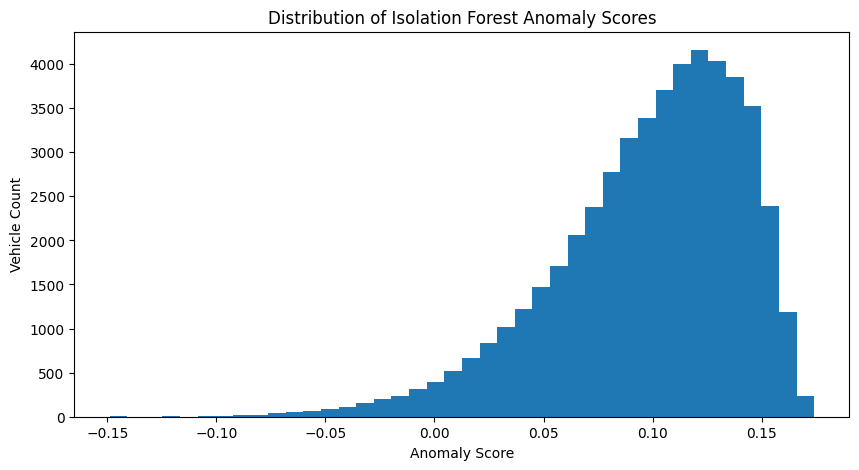

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(vehicle_features["anomaly_score"], bins=40)
plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Vehicle Count")
plt.show()

# Visual Analysis - Services vs failures colored by anomaly flag

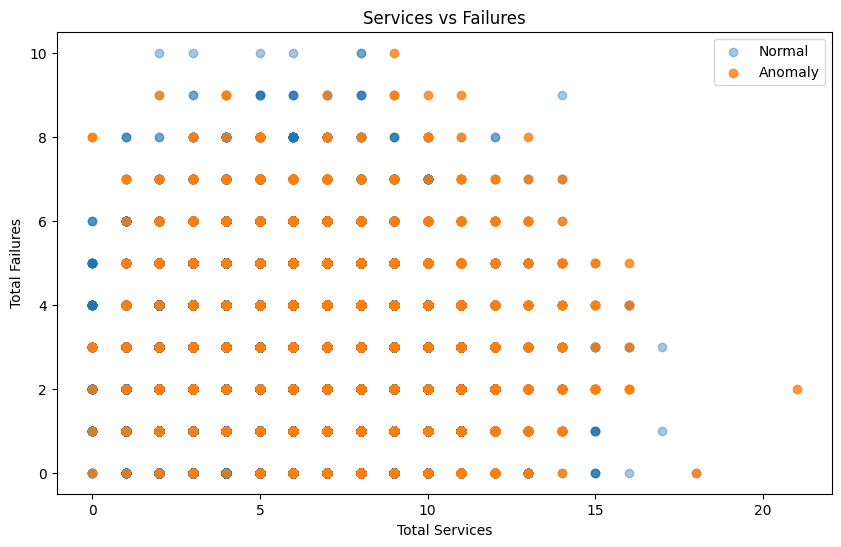

In [20]:
plt.figure(figsize=(10, 6))

normal = vehicle_features[vehicle_features["anomaly_flag"] == 0]
anomaly = vehicle_features[vehicle_features["anomaly_flag"] == 1]

plt.scatter(normal["total_services"], normal["total_failures"], alpha=0.4, label="Normal")
plt.scatter(anomaly["total_services"], anomaly["total_failures"], alpha=0.8, label="Anomaly")

plt.xlabel("Total Services")
plt.ylabel("Total Failures")
plt.title("Services vs Failures")
plt.legend()
plt.show()

# Visual Analysis - Claim amount vs warning count

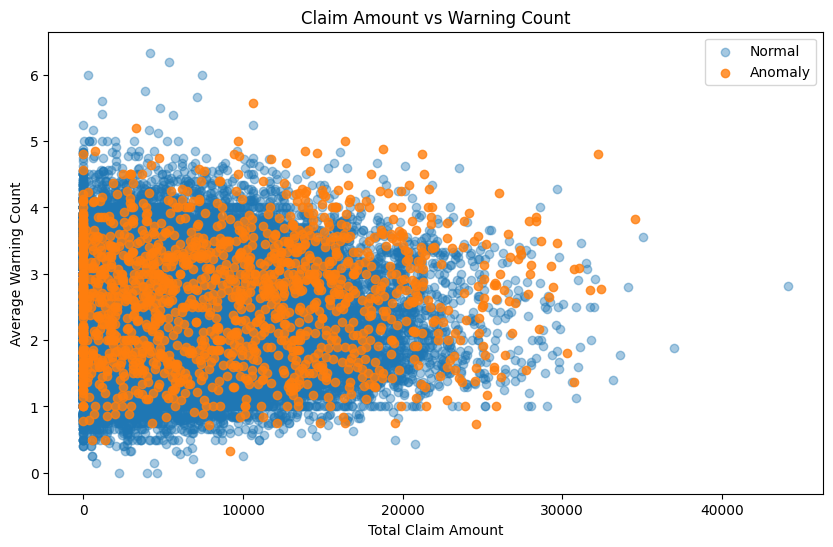

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(normal["total_claim_amount"], normal["avg_warning_count"], alpha=0.4, label="Normal")
plt.scatter(anomaly["total_claim_amount"], anomaly["avg_warning_count"], alpha=0.8, label="Anomaly")

plt.xlabel("Total Claim Amount")
plt.ylabel("Average Warning Count")
plt.title("Claim Amount vs Warning Count")
plt.legend()
plt.show()

# Visual Analysis - Battery Health vs. Failures

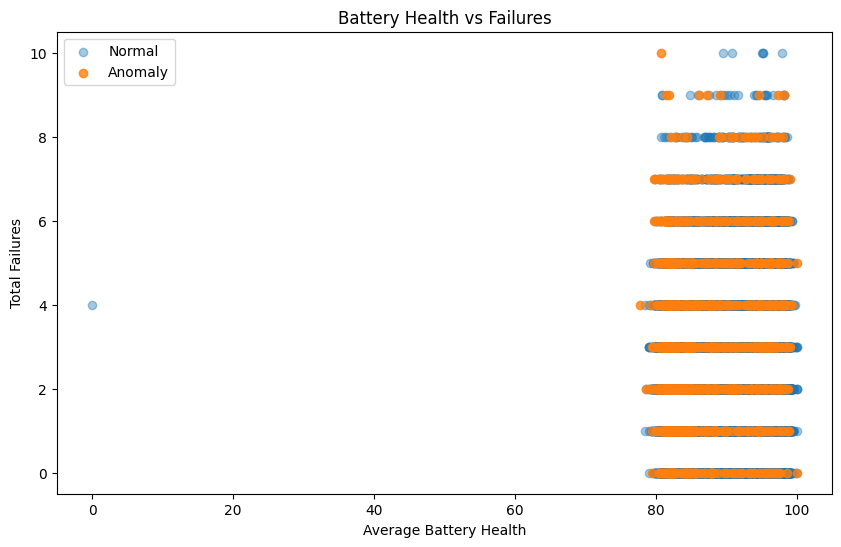

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(normal["avg_battery_health"], normal["total_failures"], alpha=0.4, label="Normal")
plt.scatter(anomaly["avg_battery_health"], anomaly["total_failures"], alpha=0.8, label="Anomaly")

plt.xlabel("Average Battery Health")
plt.ylabel("Total Failures")
plt.title("Battery Health vs Failures")
plt.legend()
plt.show()

# Summaries By Anomaly Class

# Compare averages

In [23]:
comparison_cols = [
    "total_services",
    "total_failures",
    "total_claim_amount",
    "avg_warning_count",
    "avg_battery_health",
    "total_downtime_days",
    "fleet_risk_score"
]

anomaly_summary = vehicle_features.groupby("anomaly_flag")[comparison_cols].mean().round(2)
anomaly_summary

,total_services,total_failures,total_claim_amount,avg_warning_count,avg_battery_health,total_downtime_days,fleet_risk_score
anomaly_flag,,,,,,,
0,5.94,2.38,4987.87,2.17,91.63,21.31,0.39
1,7.94,3.19,9239.19,2.64,87.79,32.02,1.29


# Anomalies by model

In [24]:
anomaly_by_model = vehicle_features.groupby("model").agg(
    total_vehicles=("vehicle_id", "count"),
    anomaly_count=("anomaly_flag", "sum")
).reset_index()

anomaly_by_model["anomaly_rate"] = (
    anomaly_by_model["anomaly_count"] / anomaly_by_model["total_vehicles"]
).round(4)

anomaly_by_model.sort_values("anomaly_rate", ascending=False)

,model,total_vehicles,anomaly_count,anomaly_rate
4,Model Y,17100,546,0.0319
1,Model 3,16909,509,0.0301
3,Model X,4931,141,0.0286
2,Model S,6090,169,0.0278
0,Cybertruck,4970,135,0.0272


# Anomalies by Region

In [25]:
anomaly_by_region = vehicle_features.groupby("region").agg(
    total_vehicles=("vehicle_id", "count"),
    anomaly_count=("anomaly_flag", "sum")
).reset_index()

anomaly_by_region["anomaly_rate"] = (
    anomaly_by_region["anomaly_count"] / anomaly_by_region["total_vehicles"]
).round(4)

anomaly_by_region.sort_values("anomaly_rate", ascending=False)

,region,total_vehicles,anomaly_count,anomaly_rate
2,Middle East,4022,132,0.0328
0,Asia Pacific,12490,385,0.0308
3,North America,22550,671,0.0298
1,Europe,10938,312,0.0285


# Plot Anomaly Rate by Model

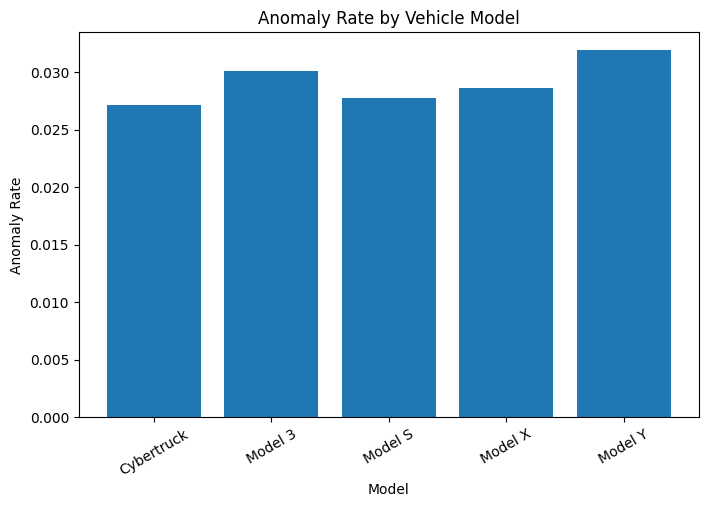

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(anomaly_by_model["model"], anomaly_by_model["anomaly_rate"])
plt.title("Anomaly Rate by Vehicle Model")
plt.xlabel("Model")
plt.ylabel("Anomaly Rate")
plt.xticks(rotation=30)
plt.show()

# Plot anomaly rate by region

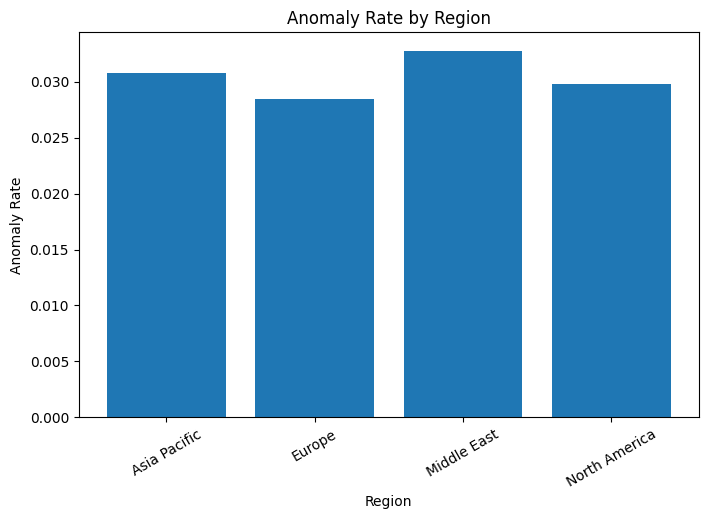

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(anomaly_by_region["region"], anomaly_by_region["anomaly_rate"])
plt.title("Anomaly Rate by Region")
plt.xlabel("Region")
plt.ylabel("Anomaly Rate")
plt.xticks(rotation=30)
plt.show()

# Create anomaly severity bucket

In [28]:
vehicle_features["anomaly_severity"] = pd.qcut(
    vehicle_features["anomaly_score"],
    q=4,
    labels=["Most Severe", "High", "Medium", "Low"]
)

In [29]:
# View most severe anomalies

most_severe = vehicle_features[
    (vehicle_features["anomaly_flag"] == 1) &
    (vehicle_features["anomaly_severity"] == "Most Severe")
].sort_values("anomaly_score")

most_severe[[
    "vehicle_id",
    "model",
    "region",
    "anomaly_score",
    "fleet_risk_score",
    "top_anomaly_drivers"
]].head(20)

,vehicle_id,model,region,anomaly_score,fleet_risk_score,top_anomaly_drivers
25208,25209,Model 3,North America,-0.148909,3,"failure_per_year, service_per_year, failures_l..."
36985,36986,Model 3,Europe,-0.142414,1,"failure_per_year, service_per_year, repairs_la..."
13095,13096,Model Y,North America,-0.141091,0,"service_per_year, failure_per_year, total_down..."
14308,14309,Model Y,Europe,-0.137200,2,"claim_per_year, service_per_year, repairs_last..."
16818,16819,Cybertruck,Asia Pacific,-0.134230,2,"service_per_year, repeat_issue_count, total_do..."
44536,44537,Model Y,Asia Pacific,-0.126624,2,"failure_per_year, service_per_year, claim_per_..."
21175,21176,Model Y,North America,-0.122046,2,"repairs_last_180d, total_claim_amount, repairs..."
20368,20369,Model S,Europe,-0.121453,2,"repairs_last_30d, repairs_last_90d, total_repa..."
26586,26587,Model 3,North America,-0.119696,2,"repairs_last_30d, total_repair_cost, repeat_is..."
46760,46761,Model Y,North America,-0.118293,3,"claim_per_year, total_claim_amount, fleet_risk..."


# Save Anomaly Results

In [30]:
vehicle_features.to_csv(f"{output_path}/vehicle_features_with_anomalies.csv", index=False)
anomalies.to_csv(f"{output_path}/anomalous_vehicles.csv", index=False)
top_anomalies.to_csv(f"{output_path}/top_anomalies_ranked.csv", index=False)
anomaly_summary.to_csv(f"{output_path}/anomaly_summary.csv")
anomaly_by_model.to_csv(f"{output_path}/anomaly_by_model.csv", index=False)
anomaly_by_region.to_csv(f"{output_path}/anomaly_by_region.csv", index=False)

print("Anomaly outputs saved successfully.")

Anomaly outputs saved successfully.


In [31]:
print("Anomaly Detection Completed Successfully")
print("Total anomalous vehicles detected:", anomalies.shape[0])
print("Output saved in:", output_path)

Anomaly Detection Completed Successfully
Total anomalous vehicles detected: 1500
Output saved in: outputs/anomaly


# Output
- Vehicle-level anomaly flags
- Ranked anomalous vehicles
- Model-wise and region-wise anomaly rates
- Inputs ready for dashboard alerts and proactive monitoring